In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [86]:
df = pd.read_csv('Customer Churn.csv')

In [87]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [88]:
# Replacing blank spaces with O, Converting totalCharges from an Object to Float

In [89]:
df['TotalCharges']=df['TotalCharges'].replace(' ',0)
df['TotalCharges']=df['TotalCharges'].astype(float)

In [90]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
# checking if customerID is repeated more than ones( duplicates if any)
df['customerID'].duplicated().sum()

np.int64(0)

In [93]:
# Currently the Senior citizen coulums defines a customer as senior citizen and tag as 'O' or '1'. Will be more easy to understand if its converted to a binary 'Yes' or 'No'

def convert(value):
  if value == 1:
    return 'Yes'
  else:
    return 'No'

df['SeniorCitizen']=df['SeniorCitizen'].apply(convert)

In [94]:
df['SeniorCitizen']

,SeniorCitizen
0,No
1,No
2,No
3,No
4,No
...,...
7038,No
7039,No
7040,No
7041,Yes


In [95]:
# Analysis


Churn Rate Analysis


In [96]:
# Customer churn refers to the percentage at which customer stop doing with a company. The above data is sourced from telecom provider. The data contains the information of its products and services and the demographcy of the cusomter along with the overall churn and retention of its customer over a period of time.

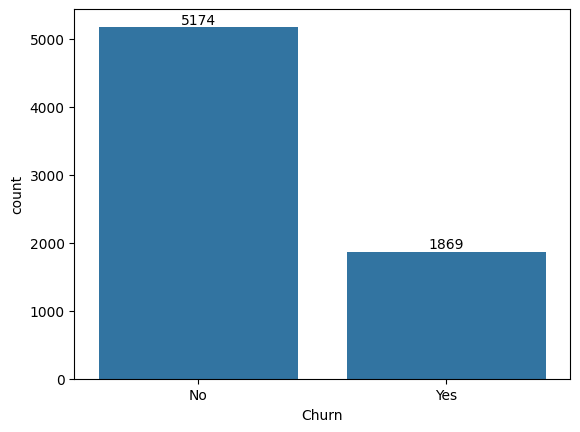

In [97]:
# Vizualzing the absolute churn rate based on the Data set
churn= sns.countplot(x='Churn',data=df)
churn.bar_label(churn.containers[0])
plt.show()

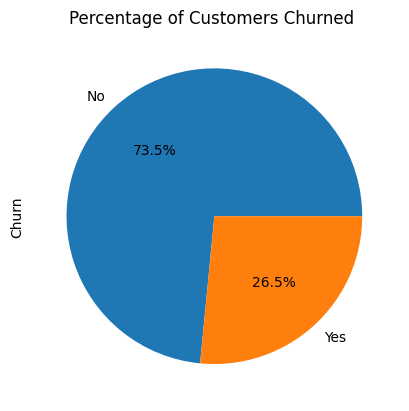

In [98]:
churn= df.groupby('Churn')['Churn'].count()
churn.plot.pie(autopct='%1.1f%%')
plt.title('Percentage of Customers Churned ')
plt.show()

In [99]:
# Analysis - Upon inspection is seen close to 26% percent of the cutomer are not comming back

In [100]:
# churn rate by contract type - Helps to indeity the churn rate across contact type (Montly,yearly,bi-annually )


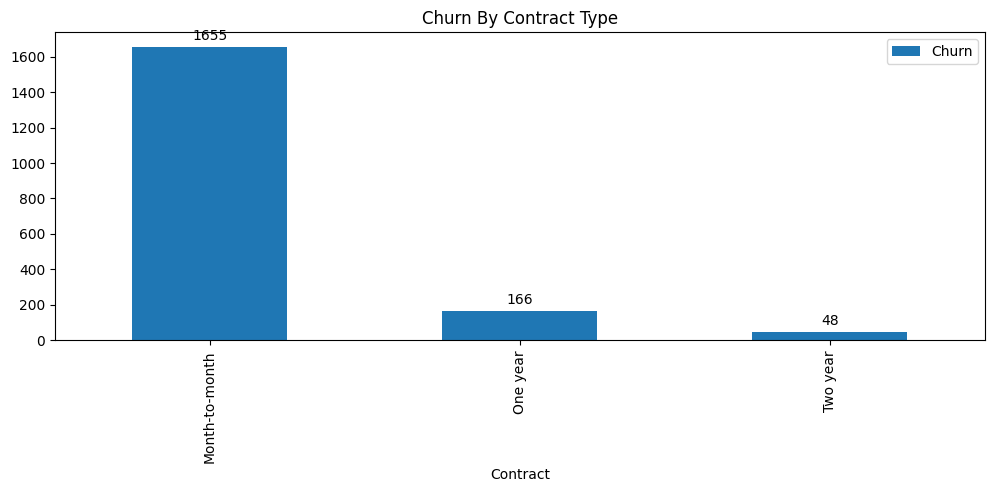

In [101]:

churn_contract=df[df["Churn"]=="Yes"]
churnby_contract=churn_contract[['Contract','Churn']]
churnby_contract2=churnby_contract.groupby('Contract').count()
#crc2.plot.bar(title='Churn by contract type',figsize=(10,5))
ax = churnby_contract2.plot.bar(title='Churn By Contract Type',figsize=(12,4))
for container in ax.containers:
    ax.bar_label(container, fmt='%g', padding=3)

In [102]:
# Upon analysis it can be determined that the highest number in loss of customer based on the contract engagement is on a monthly basis and yearly and bi-yearly remainig comparitively on the lower side

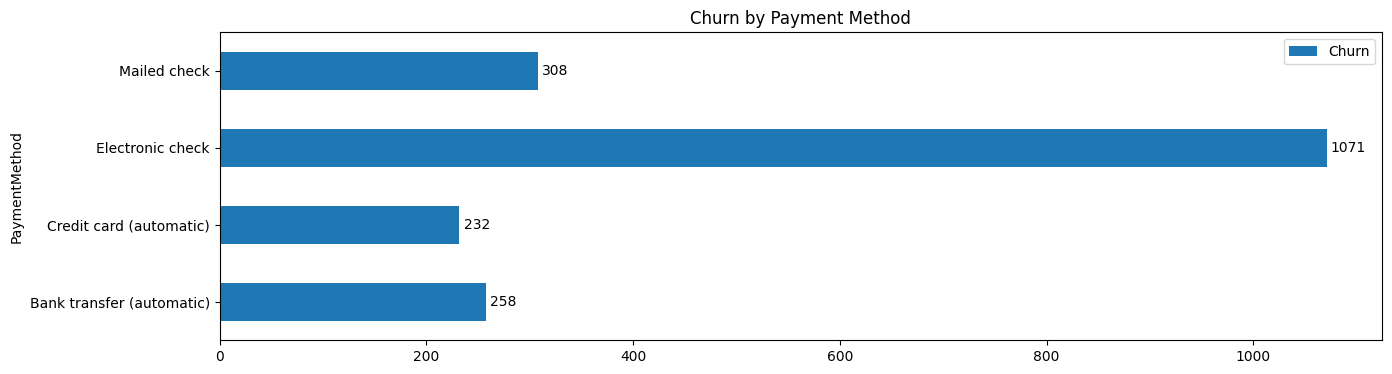

In [103]:
# churn by payment method
churnpayment=df[df["Churn"]=="Yes"]
churn_bypayment=churnpayment[['PaymentMethod','Churn']]
churn_bypayment2=churn_bypayment.groupby('PaymentMethod').count()
#cp2.plot.(title='Churn by Payment Method',figsize=(10,5))mb
ax=churn_bypayment2.plot.barh(title='Churn by Payment Method',figsize=(15,4))
for container in ax.containers:
    ax.bar_label(container, fmt='%g', padding=3)


In [104]:
# Churn rate against payment method showed customer using electronic check being the payment mode with the highest churn

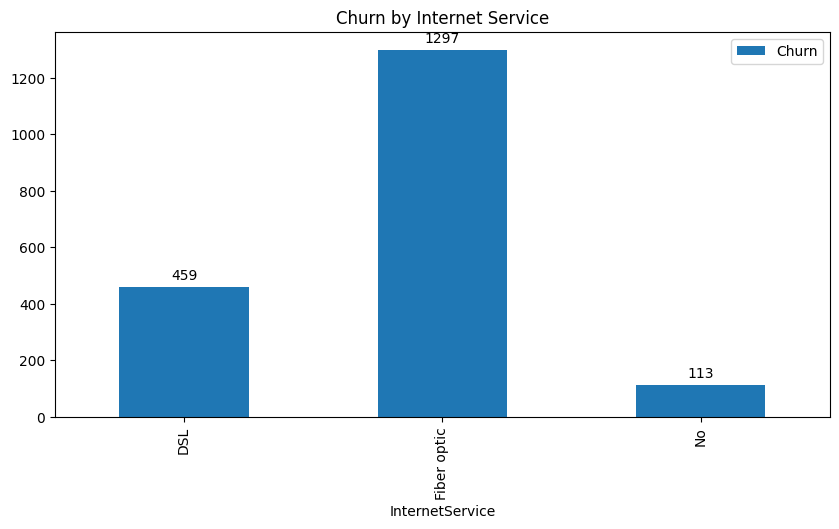

In [125]:
#Churn by Internet service
churninternet=df[df["Churn"]=="Yes"]
churnby_internet=churninternet[['InternetService','Churn']]
churnby_internet2=churnby_internet.groupby('InternetService').count()
ax=churnby_internet2.plot.bar(title='Churn by Internet Service',figsize=(10,5))
for container in ax.containers:
    ax.bar_label(container, fmt='%g', padding=3)

Revenue Impact of Churn

In [106]:
# Monthly revenue Lost
total_monthlyrevnue=df['MonthlyCharges'].sum()
lost_monthlyrevenue = df[df['Churn']=='Yes']['MonthlyCharges'].sum()
revised_monthlyrevenue=total_monthlyrevnue-lost_monthlyrevenue

total_monthly_revenue=pd.DataFrame({'Total Revenue':[total_monthlyrevnue],'Lost Revenue':[lost_monthlyrevenue],'Revised Revenue':[revised_monthlyrevenue]})
total_monthly_revenue

,Total Revenue,Lost Revenue,Revised Revenue
0,456116.6,139130.85,316985.75


In [107]:
# Total Loss
total_revenue=df['TotalCharges'].sum()
lost_revenue = df[df['Churn']=='Yes']['TotalCharges'].sum()

revised_revenue=total_revenue-lost_revenue
revised_revenue

annual_reveneu=pd.DataFrame({'Total Revenue':[total_revenue],'Lost Revenue':[lost_revenue],'Revised Revenue':[revised_revenue]})
annual_reveneu.transpose().round(2)



,0
Total Revenue,16056168.7
Lost Revenue,2862926.9
Revised Revenue,13193241.8


In [108]:
# Average Loss per churn

average_loss= total_revenue/(df['Churn']=='Yes').sum()

average_lossperchurn=pd.DataFrame({'Average Loss per Churn':[average_loss]})
average_lossperchurn.transpose().round(2)

,0
Average Loss per Churn,8590.78


Customer Life Time Analysis


In [109]:
# Average Tenure of customer (Churn vs retaining)

In [126]:
churn_tenure= df[df['Churn']=='Yes']['tenure'].count()
retaining_tenure=df[df['Churn']=='No']['tenure'].count()

averagechurn_tenure=df[df['Churn']=='No']['tenure'].mean()
averageretaining_tenure=df[df['Churn']=='Yes']['tenure'].mean()

Customer_life_cycle=pd.DataFrame({'Average Tenure of Retaining Customer':[averagechurn_tenure],'Average Tenure of Churned Customer':[averageretaining_tenure] })

Customer_life_cycle.transpose().round(2)

,0
Average Tenure of Retaining Customer,37.57
Average Tenure of Churned Customer,17.98


In [111]:
# Tenure at which the larget no. of customers churn

<Axes: title={'center': 'Churn on month-on-month basis'}, xlabel='tenure'>

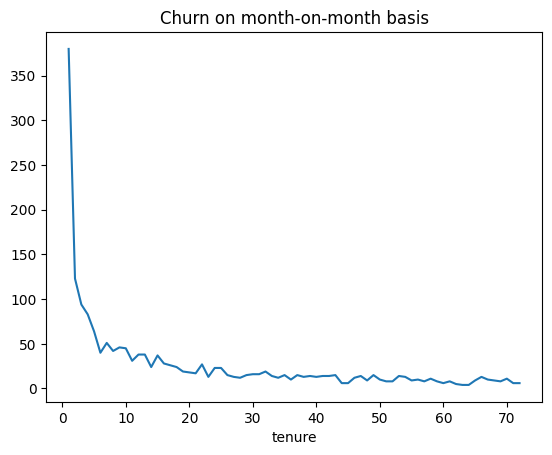

In [112]:
tenure_churn=cp.groupby('tenure')['Churn'].count()
tenure_churn
tenure_churn.plot.line(title='Churn on month-on-month basis',x='Churn',y='tenure')


<Axes: title={'center': 'Churn on annual basis'}, xlabel='tenure'>

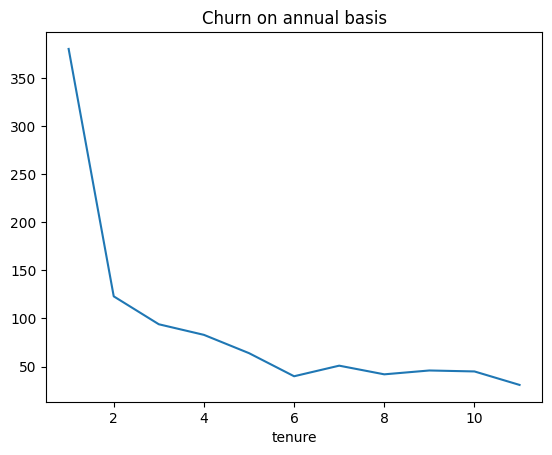

In [113]:
annual_churn=tenure_churn.where(tenure_churn.index<12)
annual_churn.plot.line(title='Churn on annual basis',x='Churn',y='tenure')mb

In [127]:
# Upon closer inspection of the data it is seen that cutomer tend to churn at the initial 0-4 months period and the churn stabilizing around the 4-5 months period

In [114]:
# Service Bundle analysis


In [115]:
# Core services are 'PhoneService'/'OnlineSecurity'/'OnlineBackup'/'DeviceProcection'/'Techsupport'/'StreamingTV'

In [116]:
core_services=df[['customerID','PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','Churn']]
core_services

,customerID,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,Churn
0,7590-VHVEG,No,No,Yes,No,No,No,No
1,5575-GNVDE,Yes,Yes,No,Yes,No,No,No
2,3668-QPYBK,Yes,Yes,Yes,No,No,No,Yes
3,7795-CFOCW,No,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Yes,No,No,No,No,No,Yes
...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Yes,Yes,No,Yes,Yes,Yes,No
7039,2234-XADUH,Yes,No,Yes,Yes,No,Yes,No
7040,4801-JZAZL,No,Yes,No,No,No,No,No
7041,8361-LTMKD,Yes,No,No,No,No,No,Yes


<Axes: >

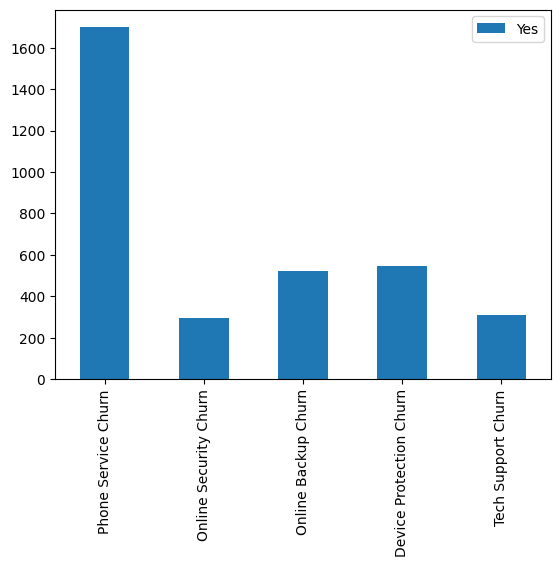

In [117]:
cs=core_services[core_services['Churn']=="Yes"]
ph_servicechurn=cs.groupby('PhoneService')['Churn'].count()
online_securitychurn=cs.groupby('OnlineSecurity')['Churn'].count()
online_backupchurn=cs.groupby('OnlineBackup')['Churn'].count()
device_protectionchurn=cs.groupby('DeviceProtection')['Churn'].count()
tech_supportchurn=cs.groupby('TechSupport')['Churn'].count()

service_churn=pd.DataFrame({'Phone Service Churn':ph_servicechurn,'Online Security Churn':online_securitychurn,'Online Backup Churn':online_backupchurn,'Device Protection Churn':device_protectionchurn,'Tech Support Churn':tech_supportchurn})

sr71=service_churn.T
sr72=sr71.drop(['No internet service','No'],axis=1)
sr72.plot.bar()

<Axes: xlabel='Bundled services'>

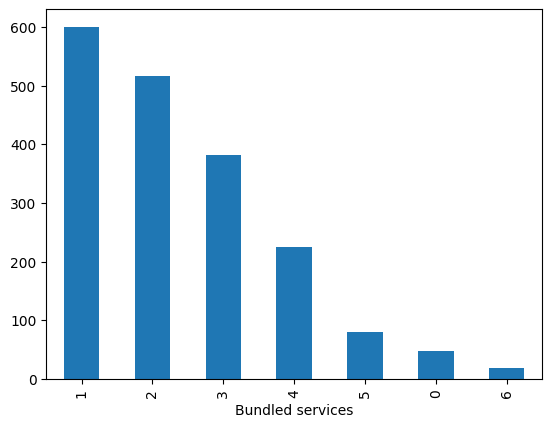

In [118]:
service_bundle=cs.groupby('customerID')[['PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV']].sum()
sr_bundle1=(service_bundle[['PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV']]=='Yes').sum(axis=1)
sr_bundle1.name = 'Bundled services'
sr_bundle2=sr_bundle1.value_counts()
sr_bundle2.plot.bar()



In [119]:
# Churn in Internet service and phone service


<Axes: title={'center': 'Churn by Internet Service'}, xlabel='InternetService'>

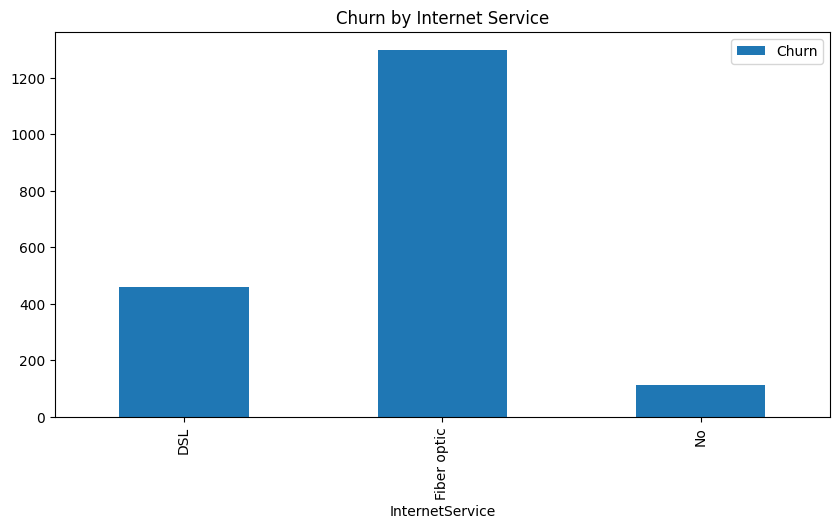

In [120]:
ci=df[df["Churn"]=="Yes"]
ci1=ci[['InternetService','Churn']]
ci2=ci1.groupby('InternetService').count()
ci2.plot.bar(title='Churn by Internet Service',figsize=(10,5))



<Axes: title={'center': 'Churn by Phone Service'}, xlabel='PhoneService'>

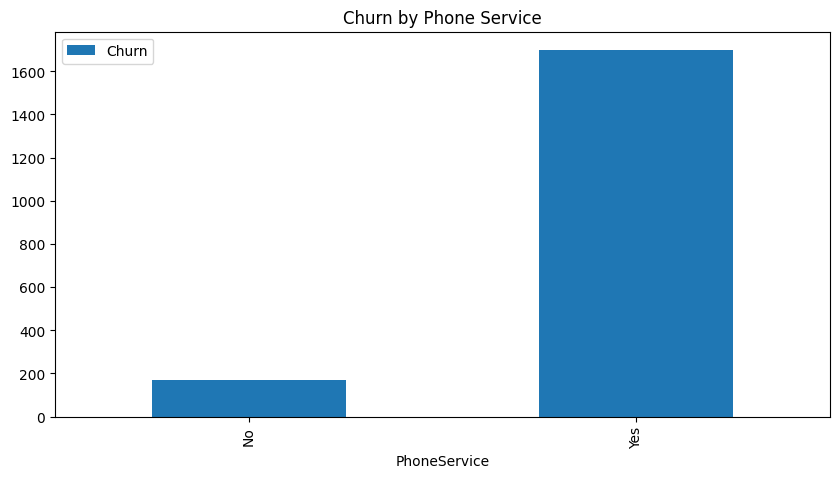

In [121]:
cp=df[df["Churn"]=="Yes"]
cp1=cp[['PhoneService','Churn']]
cp2=cp1.groupby('PhoneService').count()
cp2.plot.bar(title='Churn by Phone Service',figsize=(10,5))

In [122]:
# Customer Demography



In [123]:
# Count of customer who are seniour citzen

senior_citizen=df['SeniorCitizen'].value_counts()
senior_citizen

,count
SeniorCitizen,
No,5901
Yes,1142


In [124]:
# Seniour ciizen churn rate
senior_citizenchurn=crc['SeniorCitizen'].value_counts()
pd.DataFrame(senior_citizenchurn)

,count
SeniorCitizen,
No,1393
Yes,476


In [ ]:
# Churn Risk
